## Predistort Pulses Generated with QuDiPy

This experiment uses bias T connected between I1 and O1 of the QRM to test sample pulses generated with QuDiPy.\
Run generateIIR.ipynb first to generate some filter data. Note that this experiment isnt particularly useful because its on a 50Ohm load whereas actual quantum dot loads are high impedance.

In [1]:
fileFilterData = "FilterData.json"
fileInputWaveforms = "pulseData/Yrot_T_7us_S_triangle.json"

In [2]:
#sys.path is used to access predistort.py in parent directory
import sys, os
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath(""))))
import transferFunctionCorrection.predistort as predistort

import json
import matplotlib.pyplot as plt
from qblox_instruments import Cluster
from qblox_instruments.types import InstrumentType
import scipy.optimize
import numpy as np
import pandas as pd

#### Connect and Configure Qblox Cluster

In [3]:
#Scan for clusters
!qblox-pnp list

Devices:
 - 192.168.137.2: cluster_mm 0.6.2 with name "cluster-mm" and serial number 00015_2251_003


In [4]:
acquisitionAvgCount = 100

"""
This is a temporary file, it is deleted after upload
to the sequencer. Unique file name was chosen to ensure
no naming conflicts with other files in the directory
"""
jsonSequenceFileName = "applyIIRExampleSequence.json"

#Using a QRM
cluster = Cluster("cluster_mm", "192.168.137.2")
module = None

modules = [mod for mod in cluster.modules if mod.present()]
for mod in modules:
	if mod.module_type == InstrumentType.QRM:
		module = mod
if module == None:
	print("Error: Module of type " + str(InstrumentType.QRM) + " not found.")
	quit()

cluster.reset()
cluster.get_system_state()

#Configure sequencers for this experiment
module.scope_acq_avg_mode_en_path0(True)
module.in0_offset(-0.008)
module.in1_offset(-0.008)
module.scope_acq_sequencer_select(0)
module.scope_acq_trigger_mode_path0("sequencer")
module.scope_acq_trigger_mode_path1("sequencer")
module.disconnect_inputs()
module.disconnect_outputs()
module.sequencer0.connect_sequencer("io0_1")

def generateSequenceJson(waveform:list[float]):
	waveforms = {"block": {"data": waveform, "index": 0,},}
	acquisitions = {"response": {"num_bins": 1,"index": 0}}	
	seq_prog = f"""
			move    {acquisitionAvgCount},R0   #Loop iterator.

			loop: 	play    0,0,4     #Play waveforms and wait 4ns.
					acquire 0,0,16384
					wait	24000
					loop    R0,@loop  #Run until number of iterations is done.

					stop              #Stop.
			"""
	
	sequence = {"waveforms": waveforms,"weights": {},"acquisitions": acquisitions,"program": seq_prog,}

	#Check that file doesnt exist
	path = os.path.dirname(os.path.realpath(""))
	if (os.path.exists(path + f"/{jsonSequenceFileName}")):
		print(f"Error: The file {jsonSequenceFileName} already exists in current directory!")
		quit()

	with open(jsonSequenceFileName, "w", encoding="utf-8") as file:
		json.dump(sequence, file, indent=4)
		file.close()

def playPulse(waveform:list[float]) -> list[float]:
	generateSequenceJson(waveform)
	module.sequencer0.sequence(jsonSequenceFileName)
	os.remove(jsonSequenceFileName)

	module.arm_sequencer(0)
	module.start_sequencer()
	module.get_sequencer_state(0, timeout=1)
	module.get_acquisition_state(0, 1)
	module.store_scope_acquisition(0, "response")
	acqData = module.get_acquisitions(0)
	module.delete_acquisition_data(0, all=True)
	return acqData["response"]["acquisition"]["scope"]["path0"]["data"]

#### Load Filter Data

In [5]:
iterationData = None
with open(fileFilterData, encoding="utf-8") as file:
	iterationData = json.load(file)
	file.close()

#### Load Pulse Data

In [6]:
pulseData = None
with open(fileInputWaveforms, encoding="utf-8") as file:
	pulseData = json.load(file)
	file.close()

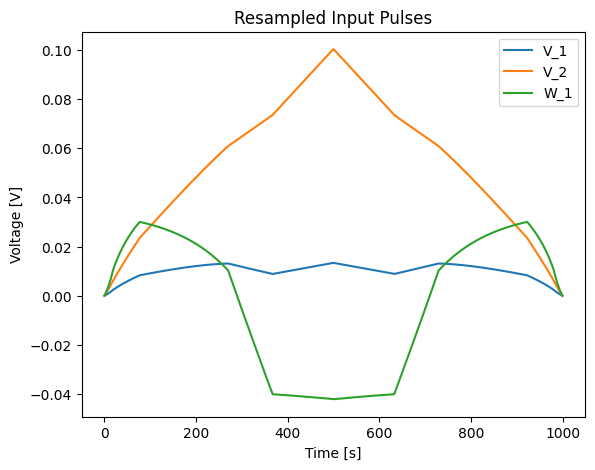

In [7]:
V_1 = (np.array(pulseData["$V_1$"])).tolist()
V_2 = (np.array(pulseData["$V_2$"])).tolist()
W_1 = pulseData["$W_1$"]

#Subtract the first value of the array to remove DC offset
V_1 = ((np.array(V_1) - V_1[0])).tolist()
V_2 = ((np.array(V_2) - V_2[0])).tolist()
W_1 = ((np.array(W_1) - W_1[0])).tolist()

fig, ax = plt.subplots(1, 1, figsize=(6.5, 5))
ax.plot(V_1, label="V_1")
ax.plot(V_2, label="V_2")
ax.plot(W_1, label="W_1")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Voltage [V]")
ax.set_title("Resampled Input Pulses")
ax.legend()
plt.show()

#### Test Filters on Different Waveforms and Plot Results

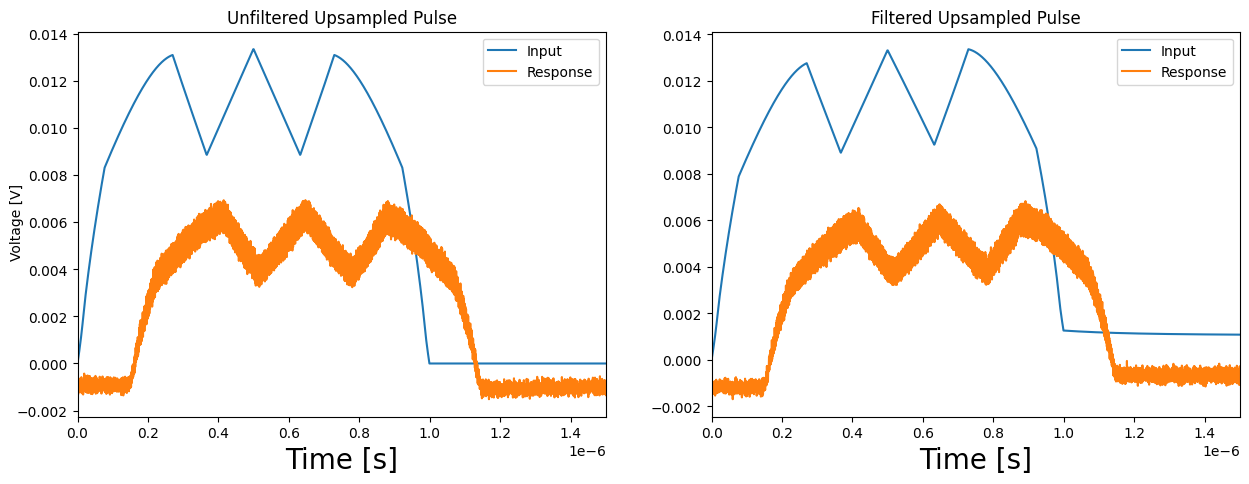

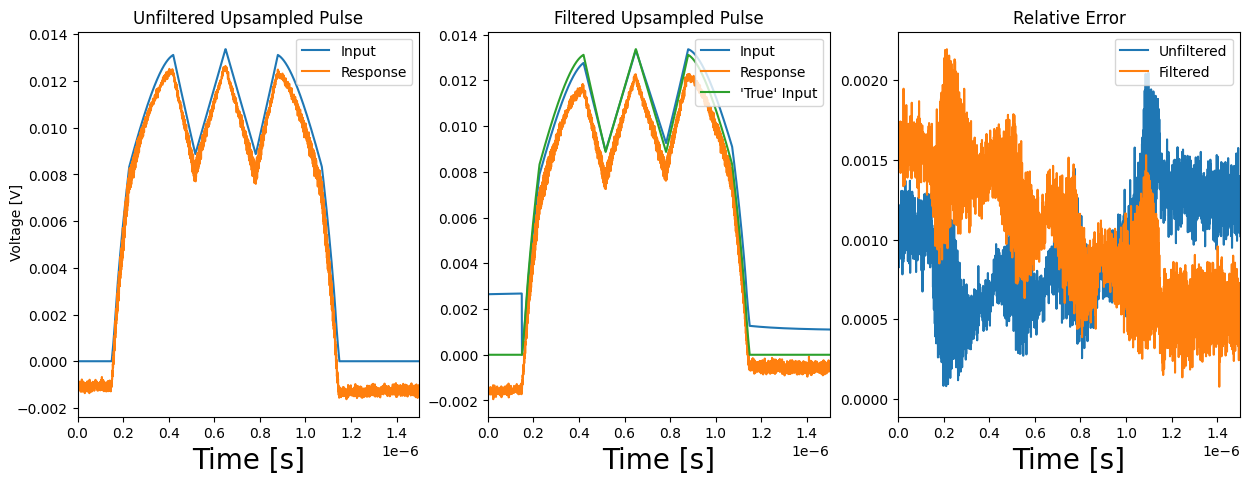

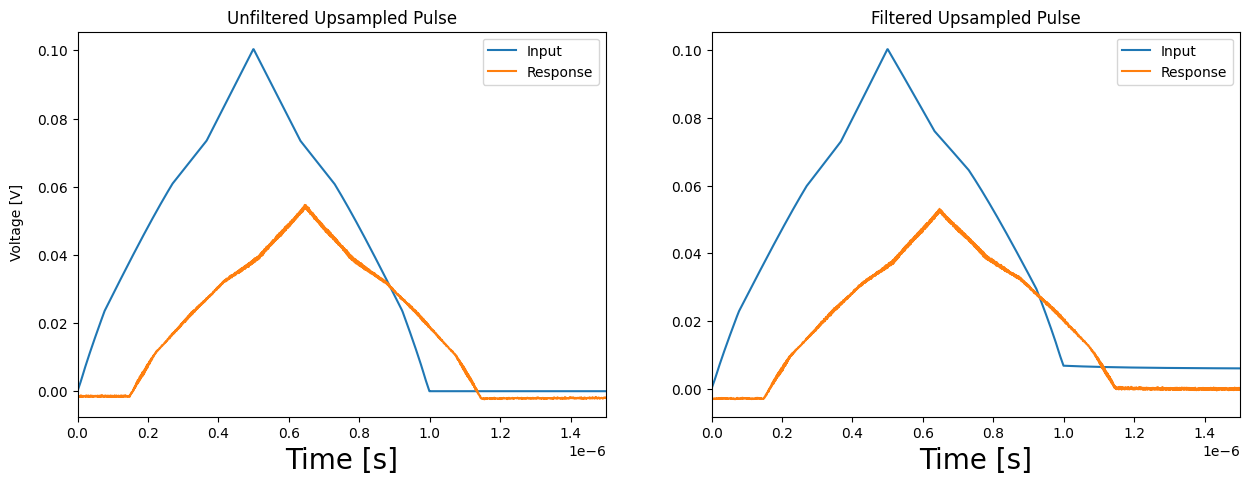

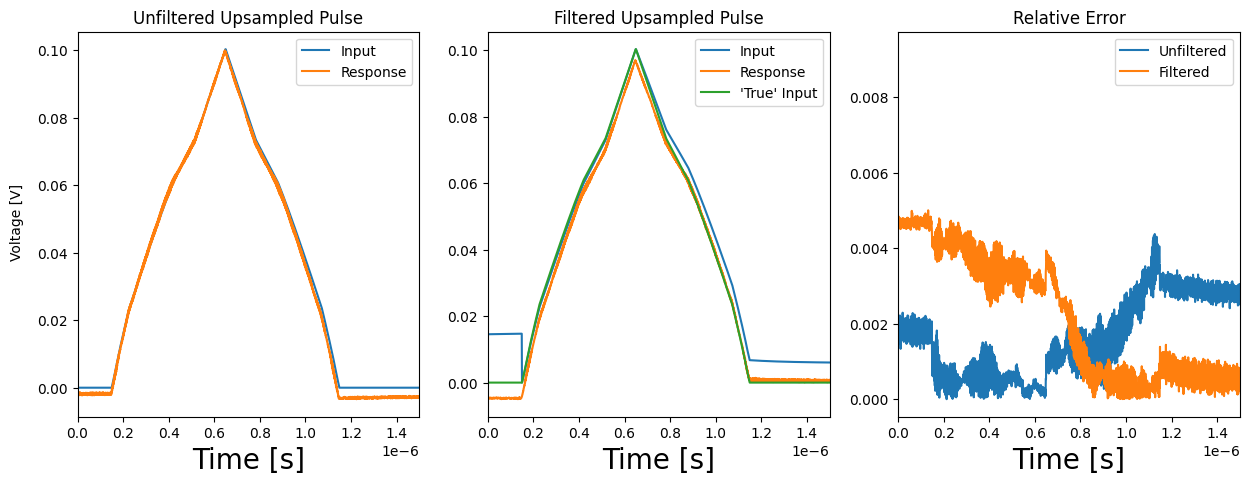

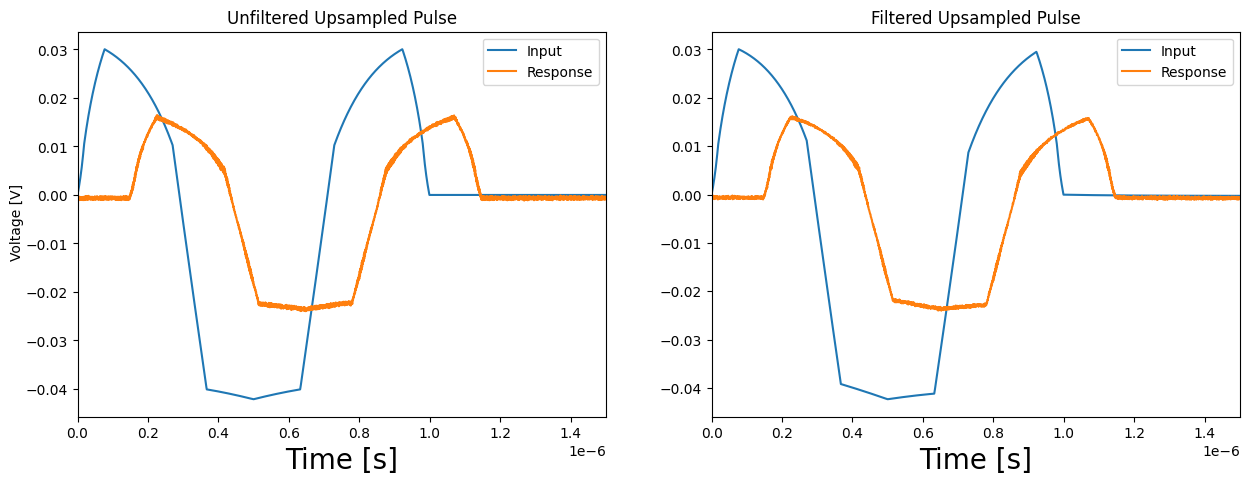

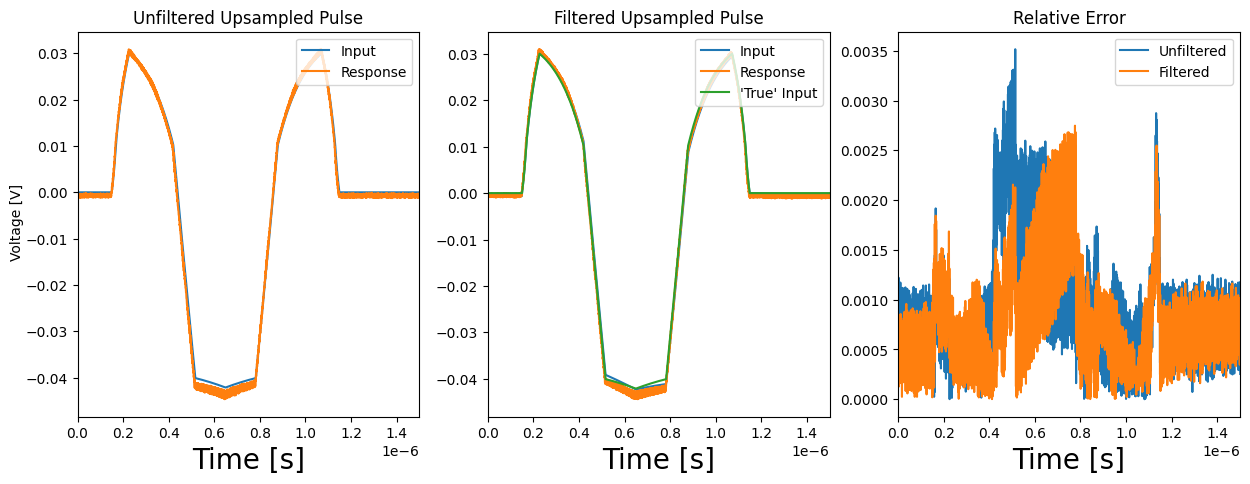

In [8]:
#Test filters on some waveforms
samplePeriodAwg = 1e-9
acqMaxTime = 16384	#Waveform acquisition, defined by Qblox
xData = [i*samplePeriodAwg for i in range(acqMaxTime)] #Convert from samples to time

def plotData(unfilteredInput, filteredInput, title, show=True):

	unfilteredOutput = playPulse((np.array(unfilteredInput)).tolist())
	filteredOutput = playPulse((np.array(filteredInput)).tolist())
	fig, ax = plt.subplots(1, 2, sharex=True, figsize = (15, 5))
	ax[0].plot(xData, unfilteredInput, label="Input")
	ax[0].plot(xData, unfilteredOutput, label="Response")
	ax[0].set_title("Unfiltered " + title)
	ax[0].legend(loc="upper right")
	ax[0].set_xlabel("Time [s]", fontsize=20)
	ax[1].set_xlabel("Time [s]", fontsize=20)
	ax[1].plot(xData, filteredInput, label="Input")
	ax[1].plot(xData, filteredOutput, label="Response")
	ax[1].set_title("Filtered " + title)
	ax[1].legend(loc="upper right")

	fig.text(0.08, 0.5, 'Voltage [V]', va='center', rotation='vertical')

	ax[0].set_xlim(0, 0.15e-5)
	ax[1].set_xlim(0, 0.15e-5)
	if show:
		plt.show()

	unfilteredOutput = playPulse((1.87*np.array(unfilteredInput)).tolist())
	filteredOutput = playPulse((1.87*np.array(filteredInput)).tolist())
	fig, ax = plt.subplots(1, 3, sharex=True, figsize = (15, 5))
	ax[0].plot(xData, np.roll(np.array(unfilteredInput),150), label="Input")
	ax[0].plot(xData, unfilteredOutput, label="Response")
	ax[0].set_xlabel("Time [s]", fontsize=20)
	ax[0].set_title("Unfiltered " + title)
	ax[0].legend(loc="upper right")
	ax[1].plot(xData, np.roll(np.array(filteredInput),150), label="Input")
	ax[1].plot(xData, filteredOutput, label="Response")
	ax[1].plot(xData, np.roll(np.array(unfilteredInput),150), label="'True' Input")
	ax[1].set_xlabel("Time [s]", fontsize=20)
	ax[1].set_title("Filtered " + title)
	ax[1].legend(loc="upper right")
	ax[2].plot(xData,np.absolute(np.roll(np.array(unfilteredInput),150) - np.array(unfilteredOutput)), label="Unfiltered")
	ax[2].plot(xData,np.absolute(np.roll(np.array(unfilteredInput),150) - np.array(filteredOutput)), label="Filtered")
	ax[2].set_xlabel("Time [s]", fontsize=20)
	ax[2].set_title("Relative Error")
	ax[2].legend(loc="upper right")
	
	ax[0].set_xlim(0, 0.15e-5)
	ax[1].set_xlim(0, 0.15e-5)
	ax[2].set_xlim(0, 0.15e-5)

	fig.text(0.08, 0.5, 'Voltage [V]', va='center', rotation='vertical')
	if show:
		plt.show()
	return fig, ax

pulseDuration = 1000
resampledV_1 = scipy.signal.resample(V_1, 1000).tolist() + [0.0 for i in range(acqMaxTime - 1000)]
filteredPulse = predistort.applyFiltersToWaveform(iterationData, resampledV_1)
filteredPulse = ((max(resampledV_1)*np.array(filteredPulse)/(max(filteredPulse)))).tolist()

fig, ax = plotData(resampledV_1, filteredPulse, "Upsampled Pulse")

pulseDuration = 1000
resampledV_2 = scipy.signal.resample(V_2, 1000).tolist() + [0.0 for i in range(acqMaxTime - 1000)]
filteredPulse = predistort.applyFiltersToWaveform(iterationData, resampledV_2)
filteredPulse = ((max(resampledV_2)*np.array(filteredPulse)/(max(filteredPulse)))).tolist()
fig, ax = plotData(resampledV_2, filteredPulse, "Upsampled Pulse")

pulseDuration = 1000
resampledW_1 = scipy.signal.resample(W_1, 1000).tolist() + [0.0 for i in range(acqMaxTime - 1000)]
filteredPulse = predistort.applyFiltersToWaveform(iterationData, resampledW_1)
filteredPulse = ((max(resampledW_1)*np.array(filteredPulse)/(max(filteredPulse)))).tolist()
fig, ax = plotData(resampledW_1, filteredPulse, "Upsampled Pulse")